In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
import os
from telco_churn.data_preparation import load_telco_customers_from_db
from telco_churn.toolkit_functions import clean_columns
from telco_churn.toolkit_functions import handle_duplicates
from telco_churn.toolkit_functions import report_nan
from telco_churn.plots import save_plot
from telco_churn.data_preparation import save_dataframe_to_csv

In [2]:
DATA_LOADING_VALIDATION_PLOTS_PATH = "../reports/figures/data_loading_validation"
PROCESSED_DATA_PATH = "../data/processed"

## Load data from PostgreSQL

The dataset is loaded from the `telco_customers` table in PostgreSQL.

The database URL is stored in a local `.env` file instead of the notebook to keep private data outside the repository.

In [3]:
# Load database URL

load_dotenv()
db_url = os.getenv("DB_URL")

# Load telco customers table into a pandas DataFrame

df = load_telco_customers_from_db(db_url)

In [4]:
# Inspect first five rows

df.head()

,customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,...,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
# Check raw DataFrame dimensions

df.shape

(7043, 21)

## Create a clean DataFrame copy

This step includes:
- Creating a clean copy of the original DataFrame.
- Standardizing column names.
- Validating DataFrame dimensions, column names, and data types.

In [6]:
# Create clean_df and standardize column names

df_clean = df.copy()
df_clean = clean_columns(df_clean, deal_dups='rename')

In [7]:
# Check df_clean dimensions

df_clean.shape

(7043, 21)

In [8]:
# Check df_clean standardized column names

df_clean.columns.tolist()

['customer_id',
 'gender',
 'senior_citizen',
 'partner',
 'dependents',
 'tenure',
 'phone_service',
 'multiple_lines',
 'internet_service',
 'online_security',
 'online_backup',
 'device_protection',
 'tech_support',
 'streaming_tv',
 'streaming_movies',
 'contract',
 'paperless_billing',
 'payment_method',
 'monthly_charges',
 'total_charges',
 'churn']

In [9]:
# Verify df_clean data types

df_clean.dtypes

customer_id           object
gender                object
senior_citizen         int64
partner               object
dependents            object
tenure                 int64
phone_service         object
multiple_lines        object
internet_service      object
online_security       object
online_backup         object
device_protection     object
tech_support          object
streaming_tv          object
streaming_movies      object
contract              object
paperless_billing     object
payment_method        object
monthly_charges      float64
total_charges        float64
churn                 object
dtype: object

## Duplicates and missing values

This step focuses on:

- Checking whether `customer_id` represents one unique customer per row
- Generating a missing values report, with special focus on the target column `churn`

In [10]:
# Check duplicate customer IDs

handle_duplicates(df_clean, subset='customer_id', action='report')

{'subset_used': ['customer_id'], 'total_num': np.int64(0), 'total_pct': 0.0}

In [11]:
# Generate missing values report with separate target check

report_nan(df_clean, target='churn')

{'total_nan': np.int64(0),
 'columns_with_nan': [],
 'target': {'column_name': 'churn',
  'nan_total': np.int64(0),
  'nan_pct': np.float64(0.0)}}

## Create categorical and numerical column lists

Categorical and numerical columns are selected based on data types, with two manual adjustments:

Categorical columns:
- Add `senior_citizen`: it has a numeric data type but it represents a binary categorical feature.
- Remove `customer_id`: it is an identifier, not an analytical feature.

Numerical columns:
- Remove `senior_citizen`: it is handled as a categorical feature.

In [12]:
# Categorical columns

categorical_columns = df_clean.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

if 'senior_citizen' not in categorical_columns:
    categorical_columns.append('senior_citizen')

if 'customer_id' in categorical_columns:
    categorical_columns.remove('customer_id')

# Numerical columns

numerical_columns = df_clean.select_dtypes(include='number').columns.tolist()

if 'senior_citizen' in numerical_columns:
    numerical_columns.remove('senior_citizen')

## Categorical columns: unique values and counts

This step checks whether categorical columns contain expected values and whether any unexpected categories appear after loading the data.

In [13]:
for col in categorical_columns:
    display(df_clean[col].value_counts())
    print()

gender
Male      3555
Female    3488
Name: count, dtype: int64

partner
No     3641
Yes    3402
Name: count, dtype: int64

dependents
No     4933
Yes    2110
Name: count, dtype: int64

phone_service
Yes    6361
No      682
Name: count, dtype: int64

multiple_lines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

...

contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

paperless_billing
Yes    4171
No     2872
Name: count, dtype: int64

payment_method
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

churn
No     5174
Yes    1869
Name: count, dtype: int64

senior_citizen
0    5901
1    1142
Name: count, dtype: int64

## Numerical columns: statistical summary and distributions

This step provides a basic overview of numerical columns.  
Summary statistics are used to check whether minimum and maximum values look reasonable, while histograms provide a quick view of feature distributions.

In [14]:
# Summarize numerical columns

df_clean[numerical_columns].describe()

,tenure,monthly_charges,total_charges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304
std,24.559481,30.090047,2266.794470
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


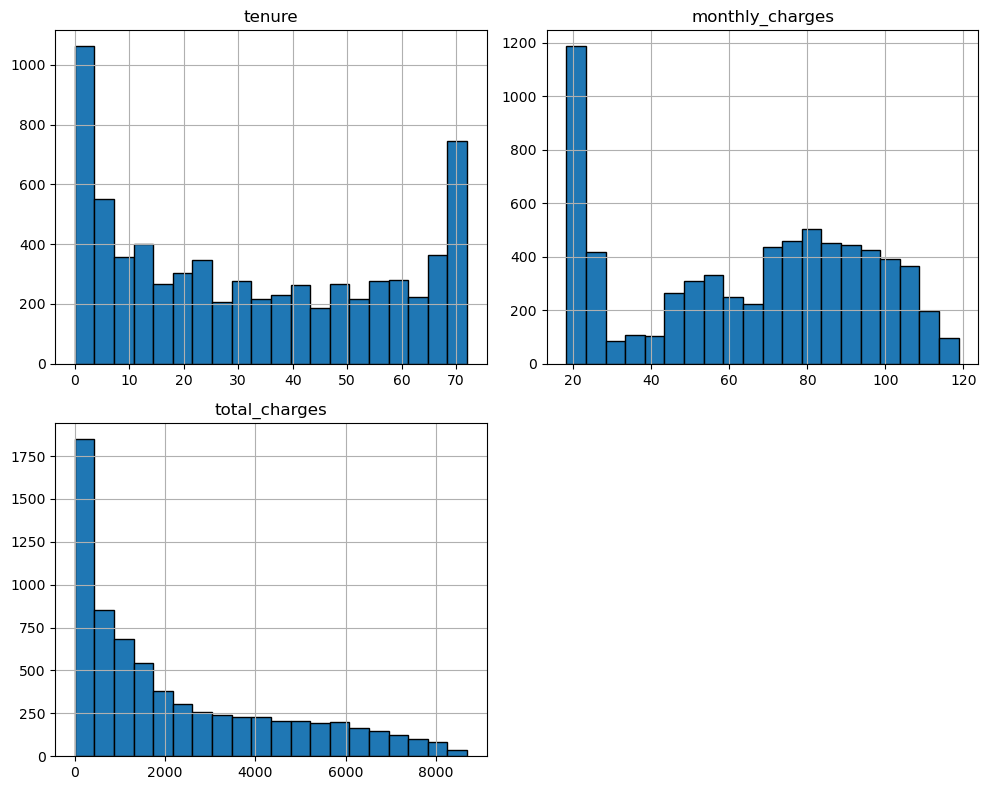

In [15]:
# Plot and save numerical columns histograms

df_clean[numerical_columns].hist(bins=20, figsize=(10,8), edgecolor='black', sharex=False, sharey=False)
plt.tight_layout()

save_plot(
    path=DATA_LOADING_VALIDATION_PLOTS_PATH,
    file_name='numerical_columns_histogram'
)

plt.show()

Numerical features are not normally distributed. `tenure` has strong peaks among new and long-tenure customers, `monthly_charges` shows visible customer segments, and `total_charges` is right-skewed with many low values.

## ## Save clean DataFrame to CSV

In [16]:
df_clean_path = save_dataframe_to_csv(
    df=df_clean, 
    path=PROCESSED_DATA_PATH,
    file_name='telco_customers_clean'
)

## Summary

The data loading and validation step confirms that the dataset is ready for train-test split and further EDA.

Key outputs from this notebook:
- Clean DataFrame saved to `data/processed/telco_customers_clean.csv`
- Numerical histogram saved to `reports/figures/data_loading_validation/numerical_columns_histogram.png`